<a href="https://colab.research.google.com/github/PranavRoy24/Logicmojo-AI-ML-Sept25-Pranav/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering

**Agenda**
1. Introduction to Feature Engineering
2. Basics of Feature Engineering
   * Feature Selection
   * Handling Missing Data
3. Intermediate Level Feature Engineering
4. Advanced Feature Engineering
5. Feature Engineering Pipeline
6. Importing Loan Prediction Dataset


### Introduction to Feature Engineering


* Feature engineering is the process of transforming raw data into features that better represent the underlying problem to predictive models. This improves the model's performance. It involves selecting, modifying, and creating features (variables) from raw data to help a machine learning model learn patterns effectively.

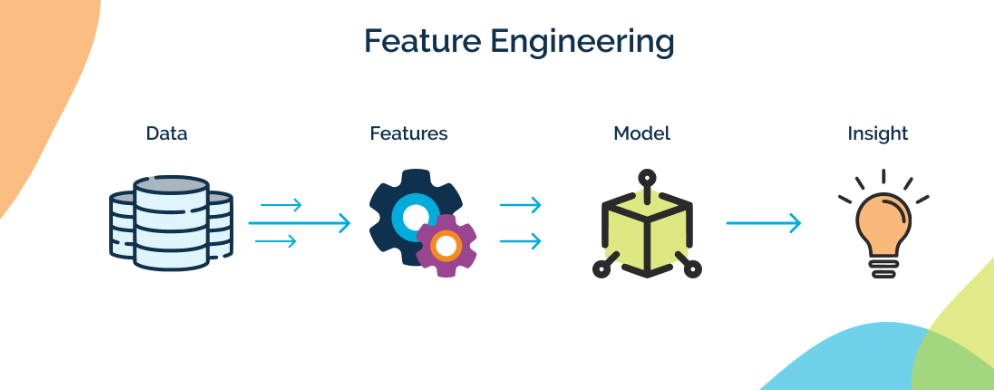

* Key Terms:
   * Feature: A measurable property of the data. For example, in a dataset of houses, "number of rooms" could be a feature.
   * Feature Set: The collection of all features used to train a model.
   * Feature Space: The multi-dimensional space formed by the features. Each axis represents one feature.


###  Basics of Feature Engineering

#### Feature Selection

* Selecting a subset of relevant features for model building can improve accuracy, reduce overfitting, and decrease model complexity.

* Techniques:

   * Filter Method: Use statistical tests (like chi-square, ANOVA) to select relevant features.
   * Wrapper Method: Use algorithms like Recursive Feature Elimination (RFE).
   * Embedded Method: Features are selected while the model is being built (e.g., Lasso Regression).

#### Handling Missing Data

* Missing data can reduce model performance or even cause failures in algorithms. Common techniques include:
   * Mean/Median/Mode Imputation: Replacing missing values with the average, median, or mode.
   * Forward or Backward Filling: Filling missing values based on neighboring data points.
   * K-Nearest Neighbors (KNN) Imputation: Filling missing values based on the nearest data points.

### Intermediate Level Feature Engineering

#### Feature Scaling (Normalization and Standardization)

* Scaling features ensures that each feature contributes equally to the result, especially for distance-based algorithms (e.g., KNN, SVM).

* Techniques:

   * Normalization (Min-Max Scaling): Rescaling features to a fixed range, usually [0, 1].
   * Standardization (Z-Score Scaling): Rescaling features to have a mean of 0 and a standard deviation of 1.

#### Encoding Categorical Variables

- Encoding categorical variables is essential in preparing data for machine learning models that require numerical input.
- Categorical data can be nominal (no order) or ordinal (with order), and different encoding methods are used based on the type of categorical data.

##### **One-Hot Encoding:**

- One-hot encoding converts categorical variables into a series of binary columns.
- Each unique category in a variable is represented by a separate column, and a row contains a 1 in the column corresponding to its category and 0s in the other columns.
- **Use Case:** Ideal for nominal data where categories do not have an intrinsic order.
- **"Intrinsic order"** refers to a natural or inherent ranking or sequence that exists within a set of categorical data. This order implies a meaningful progression or hierarchy among the categories. In the context of ordinal variables in statistics or machine learning:
  - **Ordinal Variables:**These are categorical variables where the categories can be ranked or ordered. For example, ratings such as "low," "medium," and "high" have a clear intrinsic order from lowest to highest.
  - **Intrinsic Order:** It denotes that the order of the categories carries important information or meaning. This order is not arbitrary but reflects a qualitative or quantitative relationship between the categories.



In [ ]:
import pandas as pd

data = {
    'A': [1, 2, 3, 4, 5],
    'B': ['cat', 'dog', 'cat', 'bird', 'dog']
}
print("Before One Hot Encoding")
df = pd.DataFrame(data)
print(df.head())
print("After One Hot Encoding")
df_one_hot = pd.get_dummies(df, columns=['B'])
print(df_one_hot)

Before One Hot Encoding
   A     B
0  1   cat
1  2   dog
2  3   cat
3  4  bird
4  5   dog
After One Hot Encoding
   A  B_bird  B_cat  B_dog
0  1   False   True  False
1  2   False  False   True
2  3   False   True  False
3  4    True  False  False
4  5   False  False   True


##### **Label Encoding:**

- Label encoding assigns a unique integer to each category. This method is simple and effective but can introduce ordinal relationships that might not exist.
- **Use Case:** Suitable for ordinal data where categories have a meaningful order.

In [ ]:
# Importing necessary libraries
# scikit-learn (often abbreviated as sklearn) is a comprehensive library in Python
# for machine learning, data preprocessing, model selection, and evaluation.
from sklearn.preprocessing import LabelEncoder  # Importing LabelEncoder from sklearn.preprocessing

# Sample data creation
data = {
    'A': [1, 2, 3, 4, 5],  # Creating a numerical column 'A' with values 1 to 5
    'B': ['cat', 'dog', 'cat', 'bird', 'dog']  # Creating a categorical column 'B' with animal names
}

# Creating a DataFrame 'df' using pandas with the created sample data
df = pd.DataFrame(data)

# Creating an instance 'label_encoder' of LabelEncoder class from sklearn.preprocessing
label_encoder = LabelEncoder()

# Applying label encoding to column 'B' of DataFrame 'df'
df['B'] = label_encoder.fit_transform(df['B'])

# Printing the transformed DataFrame 'df' after label encoding
print(df)

   A  B
0  1  1
1  2  2
2  3  1
3  4  0
4  5  2


(where 'bird' -> 0, 'cat' -> 1, 'dog' -> 2)

##### **Ordinal Encoding:**

- Ordinal encoding is similar to label encoding but explicitly considers the order of the categories. You define the order, and each category is assigned an integer based on this order.
- **Use Case:** Suitable for ordinal data where the order of categories matters.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
data = {
    'A': [1, 2, 3, 4, 5],
    'B': ['cat', 'dog', 'cat', 'bird', 'dog']
}
df = pd.DataFrame(data)
ordinal_categories = [['bird', 'cat', 'dog']]
# ordinal_categories = [['cat', 'bird', 'dog']]
ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)
df['B'] = ordinal_encoder.fit_transform(df[['B']])
print(df)

   A    B
0  1  1.0
1  2  2.0
2  3  1.0
3  4  0.0
4  5  2.0


(where 'bird' -> 0.0, 'cat' -> 1.0, 'dog' -> 2.0)


### Advanced Feature Engineering

#### Polynomial Features

* Transforming features into higher-dimensional spaces to capture complex relationships (useful for linear models).

#### Feature Extraction (PCA, LDA)

* Principal Component Analysis (PCA): Reduces the dimensionality of data by projecting it onto a smaller number of orthogonal axes.

* Linear Discriminant Analysis (LDA): Similar to PCA but also takes class labels into account, useful for classification tasks.

#### Time Series Feature Engineering

* For time-series data, creating time-based features like:

   * Lag Features: Features representing previous time steps.

   * Rolling Mean/Standard Deviation: For capturing trends.

### Use Case: Loan Eligibility Prediction

* Objective
   * To determine whether an applicant is eligible for a loan based on their financial and personal data, and to perform essential data preprocessing tasks to improve the quality of the dataset for machine learning models.

* Data
   * Assume you have a loan prediction dataset with the following columns:

      * ApplicantID: Unique identifier for the applicant.
      * Gender: Gender of the applicant.
      * Married: Marital status of the applicant (Yes/No).
      * Dependents: Number of dependents (0, 1, 2, 3+).
      * Education: Education level (Graduate/Not Graduate).
      * SelfEmployed: Whether the applicant is self-employed (Yes/No).
      * ApplicantIncome: Monthly income of the applicant.
      * CoapplicantIncome: Monthly income of the co-applicant.
      * LoanAmount: Total loan amount requested.
      * Loan_Amount_Term: Term of the loan in months (e.g., 360 for 30 years).
      * CreditHistory: Whether the applicant has a good credit history (1 for good, 0 for bad).
      * Property_Area: Type of property area (Urban/Semiurban/Rural).
      * Loan_Status: Whether the loan was approved (Y/N).

1. Binning the Income
   * Objective: Categorize income into bins to simplify analysis and reduce variability.
   * Example:
      * Action: Create bins for ApplicantIncome such as:
          * Low Income: < 2500
          * Middle Income: 2500–5000
          * High Income: > 5000
      * Insight:
          * You might find that middle-income applicants are more likely to get approved for loans compared to low-income applicants, as they are seen as less risky.
      * Next Step: Use this binned income data as a categorical feature for further analysis or machine learning models.
2. Checking Loan Tenure
   * Objective: Analyze how loan tenure (Loan_Amount_Term) affects loan eligibility.
   * Example:
      * Action: Group the data by different loan tenures (e.g., 12 months, 36 months, 360 months) and visualize the distribution of Loan_Status (approved or not).
      * Insight:
         * Short-term loans (12–36 months) might have higher approval rates due to lower risk for lenders, whereas long-term loans (360 months) may be more likely to be rejected or scrutinized more carefully.
      * Next Step: Consider transforming Loan_Amount_Term into a categorical feature (e.g., short-term, medium-term, long-term) to better represent this in the model.
3. Credit History and Loan Approval
   * Objective: Examine the relationship between credit history and loan approval.
   * Example:
      * Action: Create a bar plot to visualize the approval rate (Loan_Status) based on CreditHistory.
      * Insight:
         * Good credit history (CreditHistory = 1) has a strong positive correlation with loan approval, while applicants with no credit history (CreditHistory = 0) are more likely to be rejected.
      * Next Step: Feature importance can highlight the significance of CreditHistory in loan eligibility predictions. Missing credit history data can be handled carefully to avoid bias in the model.
4. Filling Missing Values
   * Objective: Handle missing values in important columns like LoanAmount, CreditHistory, and Dependents.
   * Example:
      * Action: Use appropriate imputation techniques such as:
          * Mean or median imputation for LoanAmount.
          * Mode imputation for categorical variables like CreditHistory,Dependents, and Loan_Amount_Term.
      * Insight:
           * Filling null values with the median for LoanAmount avoids skewing the dataset, while using the mode for CreditHistory ensures that the majority class is represented accurately.
      * Next Step: After handling missing values, check if the distribution of data has changed significantly and ensure that no new biases have been introduced.
5. Correlation Analysis
   * Objective: Investigate correlations between different variables to understand their impact on loan approval.
   * Example:
       * Action: Generate a correlation matrix to see the relationships between continuous variables like ApplicantIncome, CoapplicantIncome, LoanAmount, and Loan_Status.
       * Insight:
          * Negative correlation: High loan amounts tend to correlate negatively with loan approval, as lenders may view larger loans as riskier.
          * Positive correlation: Higher ApplicantIncome is positively correlated with loan approval, but the correlation may not be very strong.
       * Next Step: Based on these correlations, create derived features such as TotalIncome (sum of ApplicantIncome and CoapplicantIncome) to provide a more holistic view of the applicant's financial situation.
6. Normalization and Standardization
   * Objective: Prepare numerical variables like ApplicantIncome, CoapplicantIncome, and LoanAmount for machine learning models by scaling them.
   * Example:
       * Action:
            * Normalization: Scale ApplicantIncome and LoanAmount using min-max scaling to bring them into the [0,1] range.
            * Standardization: Use z-score standardization to center ApplicantIncome, CoapplicantIncome, and LoanAmount around a mean of 0 and standard deviation of 1, especially useful for models like logistic regression or neural networks.

       * Insight:
           * Standardized features often lead to better model convergence, especially for algorithms sensitive to feature scaling.

     * Next Step: After scaling, ensure that categorical variables are handled separately (e.g., through one-hot encoding), and proceed to model building.

### Importing Loan Prediction Dataset

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/train_u6lujuX_CVtuZ9i (1).csv')

In [ ]:
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
data.columns


Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
data_without_id = data.drop(["Loan_ID"], axis=1) # dropping Loan Id

In [ ]:
data_without_id

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Applicant_income_class,Coapplicant_income_class,total_income,total_income_class,Loan_Amount_Term_years,emi,emi_income_prec
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,High,Average,5849.0,High,30.0,0.365278,0.069112
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,High,Average,6091.0,Very High,30.0,0.355556,0.058374
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,Average,Average,3000.0,Average,30.0,0.183333,0.061111
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,Average,Average,4941.0,High,30.0,0.333333,0.067463
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,High,Average,6000.0,High,30.0,0.391667,0.065278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,Average,Average,2900.0,Average,30.0,0.197222,0.068008
610,Male,Yes,3,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,High,Average,4106.0,High,15.0,0.222222,0.054121
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,Average,Low,8312.0,High,30.0,0.702778,0.084550
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,Very High,Average,7583.0,Very High,30.0,0.519444,0.068501


In [ ]:
# segregating object types columns and non-object types column
from pandas.api.types import is_numeric_dtype
obj_cols = []
numerical_cols = []
for col in data_without_id.columns:
  if is_numeric_dtype(data_without_id[col].dtype):
    numerical_cols.append(col)
    numerical_cols.append(col)
  else:
    obj_cols.append(col)

In [ ]:
obj_cols

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status',
 'Coapplicant_income_class',
 'Applicant_income_class']

In [ ]:
numerical_cols

['ApplicantIncome',
 'ApplicantIncome',
 'CoapplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'LoanAmount',
 'Loan_Amount_Term',
 'Loan_Amount_Term',
 'Credit_History',
 'Credit_History',
 'total_income',
 'total_income',
 'Loan_Amount_Term_years',
 'Loan_Amount_Term_years',
 'emi',
 'emi',
 'emi_income_prec',
 'emi_income_prec']

In [ ]:
data["Dependents"].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,51


<Axes: >

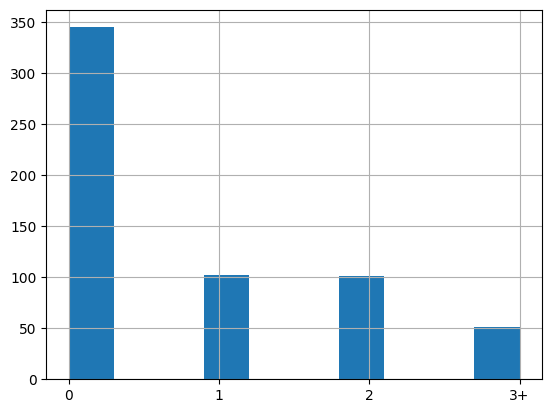

In [ ]:
data["Dependents"].hist()

#### Hypothesis:- Checking if the person is eligible for a loan or not by analyzing their income.

In [ ]:
data_without_id.groupby("Loan_Status")["ApplicantIncome"].mean()


,ApplicantIncome
Loan_Status,
N,5446.078125
Y,5384.068720


<Axes: xlabel='Loan_Status'>

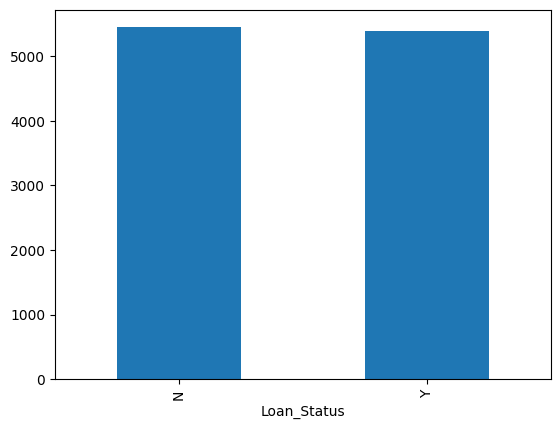

In [ ]:
data_without_id.groupby("Loan_Status")["ApplicantIncome"].mean().plot.bar()

In [ ]:
data_without_id.groupby("Loan_Status")["CoapplicantIncome"].mean()

,CoapplicantIncome
Loan_Status,
N,1877.807292
Y,1504.516398


<Axes: xlabel='Loan_Status'>

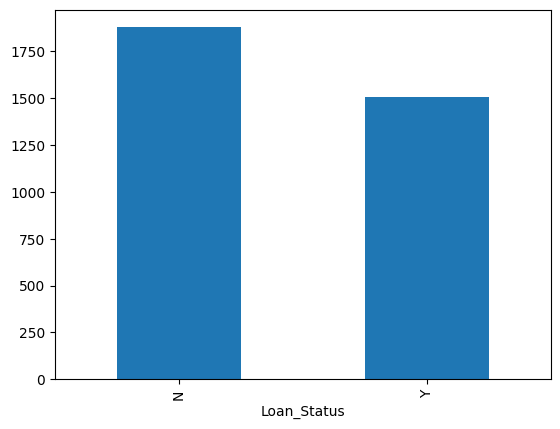

In [ ]:
data_without_id.groupby("Loan_Status")["CoapplicantIncome"].mean().plot.bar()

In [ ]:
data_without_id.groupby("Loan_Status").apply(lambda r: (r["CoapplicantIncome"]+r["ApplicantIncome"]).mean())

,0
Loan_Status,
N,7323.885417
Y,6888.585118


<Axes: >

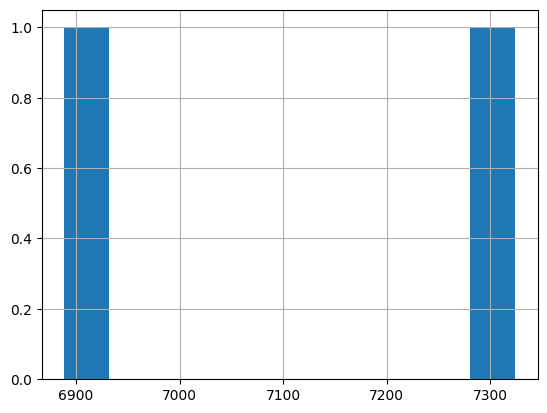

In [ ]:
data_without_id.groupby("Loan_Status").apply(lambda r: (r["CoapplicantIncome"]+r["ApplicantIncome"]).mean()).hist()

* By analyzing all these graphs, we did not find much information.

##### Bin the income

In [ ]:
bins = [0, 2500, 4000, 6000, 8000]
groups = ["Low", "Average", "High", "Very High"]

In [ ]:
pd.cut(data_without_id["ApplicantIncome"], bins, labels=groups)

,ApplicantIncome
0,High
1,High
2,Average
3,Average
4,High
...,...
609,Average
610,High
611,NaN
612,Very High


In [ ]:
data_without_id["Applicant_income_class"] = pd.cut(data_without_id["ApplicantIncome"], bins, labels=groups)

In [ ]:
# It creates 2x2 tabular format of counts.
pd.crosstab(data_without_id["Applicant_income_class"], data_without_id["Loan_Status"])


Loan_Status,N,Y
Applicant_income_class,,
Low,34,74
Average,67,159
High,45,98
Very High,20,34


**Creating new bin for Coapplicants**

In [ ]:
coapplicant_income_bins = (0, 1000, 3000, 4200)
coapplicant_income_group_name = ["Low", "Average", "High"]

In [ ]:
data_without_id["Coapplicant_income_class"] = pd.cut(data_without_id["CoapplicantIncome"], coapplicant_income_bins, labels=coapplicant_income_group_name)

In [ ]:
pd.crosstab(data_without_id["Coapplicant_income_class"], data_without_id["Loan_Status"])

Loan_Status,N,Y
Coapplicant_income_class,,
Low,3,19
Average,61,161
High,15,32


In [ ]:
data_without_id["total_income"] = data_without_id["CoapplicantIncome"] + data_without_id["ApplicantIncome"]

In [ ]:
data_without_id.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,total_income
count,614.000000,614.000000,592.000000,600.00000,564.000000,614.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199,7024.705081
std,6109.041673,2926.248369,85.587325,65.12041,0.364878,6458.663872
min,150.000000,0.000000,9.000000,12.00000,0.000000,1442.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000,4166.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000,5416.500000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000,7521.750000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000,81000.000000


**Creating new bin for total income**

In [ ]:
total_income_bins = (0, 2500, 4000, 6000, 8100)
total_income_names = ["Low", "Average", "High", "Very High"]

In [ ]:
data_without_id["total_income_class"] = pd.cut(data_without_id["total_income"], total_income_bins, labels=total_income_names)

In [ ]:
df = pd.crosstab(data_without_id["total_income_class"], data_without_id["Loan_Status"])

In [ ]:
df.div(df.sum(axis=1), axis=0)

Loan_Status,N,Y
total_income_class,,
Low,0.583333,0.416667
Average,0.268908,0.731092
High,0.290179,0.709821
Very High,0.336207,0.663793


As we can see ratio has increased drastically once you go from low total income to higher total income.

##### Checking loan Tenure

In [ ]:
data_without_id["Loan_Amount_Term_years"] = data_without_id["Loan_Amount_Term"] / 12

In [ ]:
data_without_id["Loan_Amount_Term_years"].value_counts()

,count
Loan_Amount_Term_years,
30.0,512
15.0,44
40.0,15
25.0,13
20.0,4
7.0,4
10.0,3
5.0,2
3.0,2


**Exploring Emi amounts**

In [ ]:
data_without_id["emi"] = data_without_id["LoanAmount"]/data_without_id["Loan_Amount_Term"]

<Axes: >

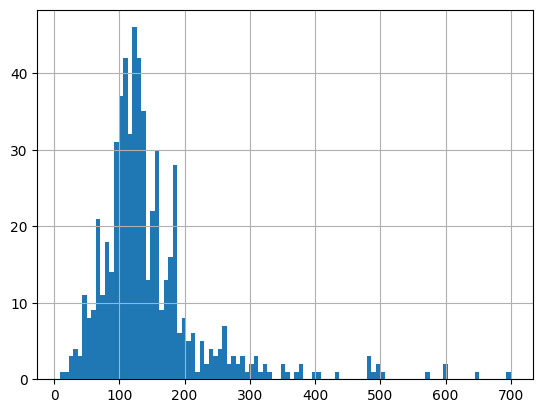

In [ ]:
data_without_id["LoanAmount"].hist(bins=100)

Over here we can see that most loans are between 0 lakh to 2 lakhs and again so therefore if the lower amount is extremely high will not be that confrontedin our results.

<Axes: >

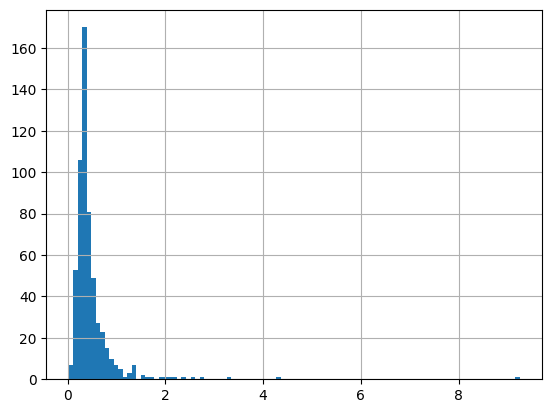

In [ ]:
data_without_id["emi"].hist(bins=100)

Most peoples are having their Emi's in between 0 to 1 thousand.

**EMI vs Income**

In [ ]:
data_without_id["emi_income_prec"] = data_without_id["emi"]/(data_without_id["total_income"]/1000)

<Axes: >

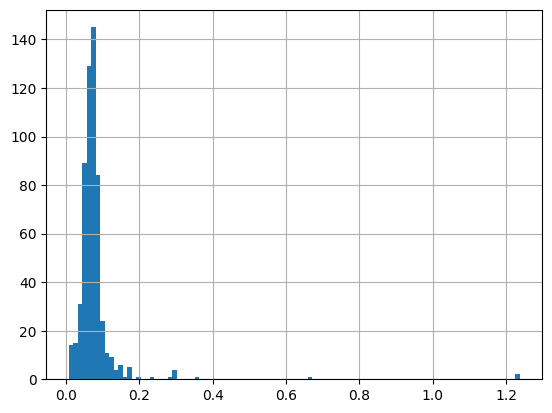

In [ ]:
data_without_id["emi_income_prec"].hist(bins=100)

Here we can see that most of the people are having an income and emi ratio in between 0 to 20 percent.

Now thresshold it to 10 percent

<Axes: xlabel='emi_income_prec'>

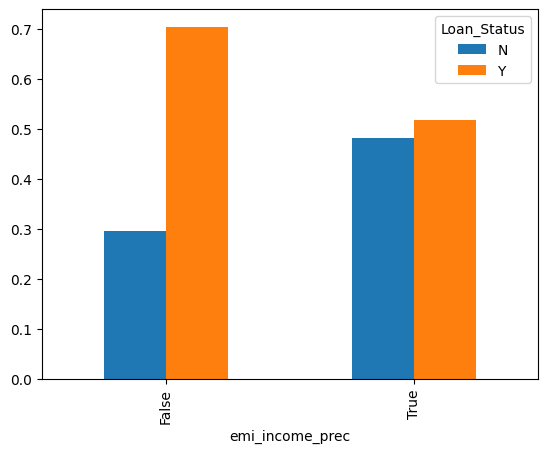

In [ ]:
df = pd.crosstab(data_without_id["emi_income_prec"] > 0.1, data_without_id["Loan_Status"])
df.div(df.sum(axis=1), axis=0).plot.bar()

* If your emi is more than 10 percent of your income then it may create dificulty in approval but if your emi is less than 10 percent of your income then you are much more likely to get an approval.

* By the help of this we can tell that a person is eligible for loan or not.

##### Checking wether Credit History matches the guidelines or not?

In [ ]:
data_without_id["Credit_History"].value_counts()

,count
Credit_History,
1.0,475
0.0,89


<Axes: xlabel='Credit_History'>

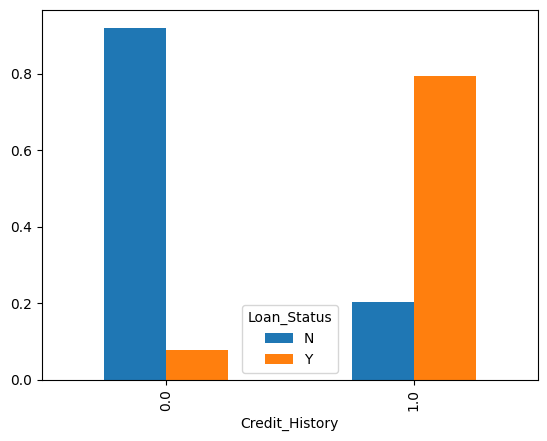

In [ ]:
df = pd.crosstab(data_without_id["Credit_History"], data_without_id["Loan_Status"])
df.div(df.sum(axis=1), axis=0).plot.bar()

* If your credit history meets the guidelines then your loan will be automatically approved.
* This is a very important feature as far as you're telling whether the loan get approved or not but it's not a feature that we can use, so always when you're doing feature engineering remember to create questions that we can ask.
* Credit history is not a askable question.

**Question:- If you're female married vs male married does it make a difference?**

##### Filling up  null values for numerical columns

In [ ]:
data_without_id.isna().sum()/len(data_without_id)/len(data_without_id)

,0
Gender,0.000034
Married,0.000008
Dependents,0.000040
Education,0.000000
Self_Employed,0.000085
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,0.000058
Loan_Amount_Term,0.000037
Credit_History,0.000133


In [ ]:
13/len(data_without_id)

0.021172638436482084

In [ ]:
numerical_cols

['ApplicantIncome',
 'ApplicantIncome',
 'CoapplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'LoanAmount',
 'Loan_Amount_Term',
 'Loan_Amount_Term',
 'Credit_History',
 'Credit_History',
 'total_income',
 'total_income',
 'Loan_Amount_Term_years',
 'Loan_Amount_Term_years',
 'emi',
 'emi',
 'emi_income_prec',
 'emi_income_prec']

In [ ]:
# Removing Credit History because it is not a numerical column
numerical_cols.remove("Credit_History")

In [ ]:
obj_cols.append("Credit_History")

In [ ]:
obj_cols

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status',
 'Coapplicant_income_class',
 'Applicant_income_class',
 'Credit_History']

In [ ]:
# Calculating median
for col in numerical_cols:
  try:
    median_income = data_without_id[col].median()
    data_without_id[col].fillna(median_income, inplace=True)
  except:
    print(col)


In [ ]:
for col in obj_cols:
    data_without_id[col].fillna(data_without_id[col].mode()[0], inplace=True)

In [ ]:
data_without_id.isna().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


Successfully remove all null values.

##### Finding Correlation

In [ ]:
data_without_id[["ApplicantIncome", "LoanAmount"]].corr()

,ApplicantIncome,LoanAmount
ApplicantIncome,1.000000,0.565181
LoanAmount,0.565181,1.000000


In [ ]:
data_without_id[["ApplicantIncome", "LoanAmount"]].corr("spearman")

,ApplicantIncome,LoanAmount
ApplicantIncome,1.000000,0.502346
LoanAmount,0.502346,1.000000


In [ ]:
x = np.array([np.random.normal() for _ in range(100)])
y = np.exp(x)

In [ ]:
df = pd.DataFrame([x, y]).T

<Axes: xlabel='0', ylabel='1'>

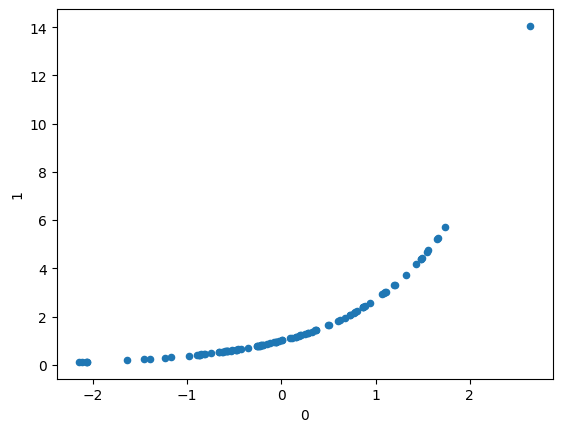

In [ ]:
df.plot.scatter(x=0, y=1)

In [ ]:
df.corr("spearman")

,0,1
0,1.0,1.0
1,1.0,1.0


##### Normalization

$$x(1i)=\frac{x-min(X)}{max(X)-min(X)}$$

Percentage of Max

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
MinMaxScaler().fit_transform(data_without_id[["LoanAmount", "ApplicantIncome"]])

array([[0.17221418, 0.07048856],
       [0.17221418, 0.05482993],
       [0.08248915, 0.03525046],
       ...,
       [0.35311143, 0.09798392],
       [0.25759768, 0.09193568],
       [0.17945007, 0.05482993]])

##### Standardiztion(z-score)

$$
x(1i)=\frac{x_i-\bar{x}}{\sigma_X}
$$

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
x = StandardScaler().fit_transform(data_without_id[["ApplicantIncome"]])

<Axes: >

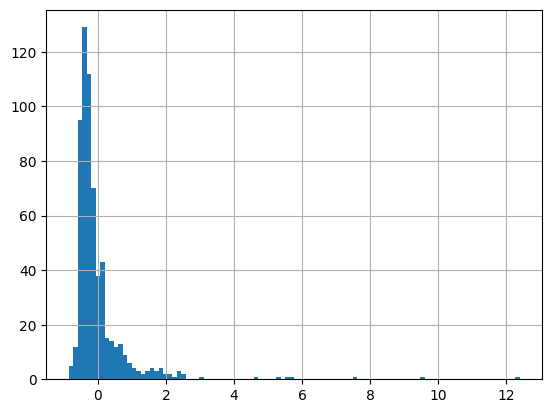

In [ ]:
pd.DataFrame(x)[0].hist(bins=100)